In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.pyplot as plt
from pywaffle import Waffle
import numpy as np


+ Create a Barplot showing cell composition of the stem cells niche

In [3]:
cell_composition = pd.read_csv('10X_Xenium_data/NicheCompass/artifacts/single_sample/21102024_150114/figures/niche_composition.csv')

In [4]:
cell_composition

,latent_leiden_0.4,Arterial capillary,B cells,BEST4+ epithelial,CD4 T,CD8 T,Colonocyte,DC,Deep_crypt_secretory,EECs,...,Microfold cell,Monocytes,Myofibroblasts,NK,Pericytes,Plasma cells,RPS10+_RPS17+_SC,TA,Tregs,Tuft cells
0,0,1,1,0,20,43,0,15,0,0,...,0,7,25360,5,217,3,0,0,0,0
1,1,26,607,1,1313,335,0,92,5,848,...,0,11,509,17,155,1129,824,1106,2,1728
2,2,6,133,0,213,134,0,30,0,2,...,0,74,107,32,4511,104,3,9,1,4
3,3,27,10939,3,6313,217,8,627,1,3,...,12,4,155,5,29,540,10,50,24,41
4,4,64,120,21,1411,367,5,199,1,32,...,0,12,370,13,83,6096,65,158,0,19
5,5,95,0,2275,1,84,12828,19,19,54,...,2,14,0,224,0,42,0,0,0,1
6,6,987,39,11,1614,317,69,1105,0,3,...,0,3,103,16,27,6749,0,18,0,0
7,7,1803,0,1065,166,103,5692,1100,12,28,...,0,1,1,93,9,453,0,2,0,4
8,8,1,2,0,98,81,0,24,0,0,...,0,258,6881,8,646,1,0,0,0,0
9,9,141,2,1037,104,136,408,54,13,138,...,0,0,12,11,2,1628,0,150,0,46


In [5]:
# Combine the columns into a new column
cell_composition['Stem cells'] = cell_composition['RPS10+_RPS17+_SC'] + cell_composition['MTRNR2L12+ASS1+_SC'] + cell_composition['FXYD3+_CKB+_SC']

# Delete the original columns
cell_composition.drop(columns=['RPS10+_RPS17+_SC', 'MTRNR2L12+ASS1+_SC', 'FXYD3+_CKB+_SC'], inplace=True)

# Display the updated dataframe
cell_composition

,latent_leiden_0.4,Arterial capillary,B cells,BEST4+ epithelial,CD4 T,CD8 T,Colonocyte,DC,Deep_crypt_secretory,EECs,...,Microfold cell,Monocytes,Myofibroblasts,NK,Pericytes,Plasma cells,TA,Tregs,Tuft cells,Stem cells
0,0,1,1,0,20,43,0,15,0,0,...,0,7,25360,5,217,3,0,0,0,0
1,1,26,607,1,1313,335,0,92,5,848,...,0,11,509,17,155,1129,1106,2,1728,4152
2,2,6,133,0,213,134,0,30,0,2,...,0,74,107,32,4511,104,9,1,4,6
3,3,27,10939,3,6313,217,8,627,1,3,...,12,4,155,5,29,540,50,24,41,87
4,4,64,120,21,1411,367,5,199,1,32,...,0,12,370,13,83,6096,158,0,19,134
5,5,95,0,2275,1,84,12828,19,19,54,...,2,14,0,224,0,42,0,0,1,0
6,6,987,39,11,1614,317,69,1105,0,3,...,0,3,103,16,27,6749,18,0,0,0
7,7,1803,0,1065,166,103,5692,1100,12,28,...,0,1,1,93,9,453,2,0,4,0
8,8,1,2,0,98,81,0,24,0,0,...,0,258,6881,8,646,1,0,0,0,0
9,9,141,2,1037,104,136,408,54,13,138,...,0,0,12,11,2,1628,150,0,46,2


In [17]:
stem_cell_niche = cell_composition.iloc[1, 1:]

In [18]:
filtered_stem_cell_niche = stem_cell_niche[stem_cell_niche >= 10]

sorted_stem_cell_niche = filtered_stem_cell_niche.sort_values(ascending=False)

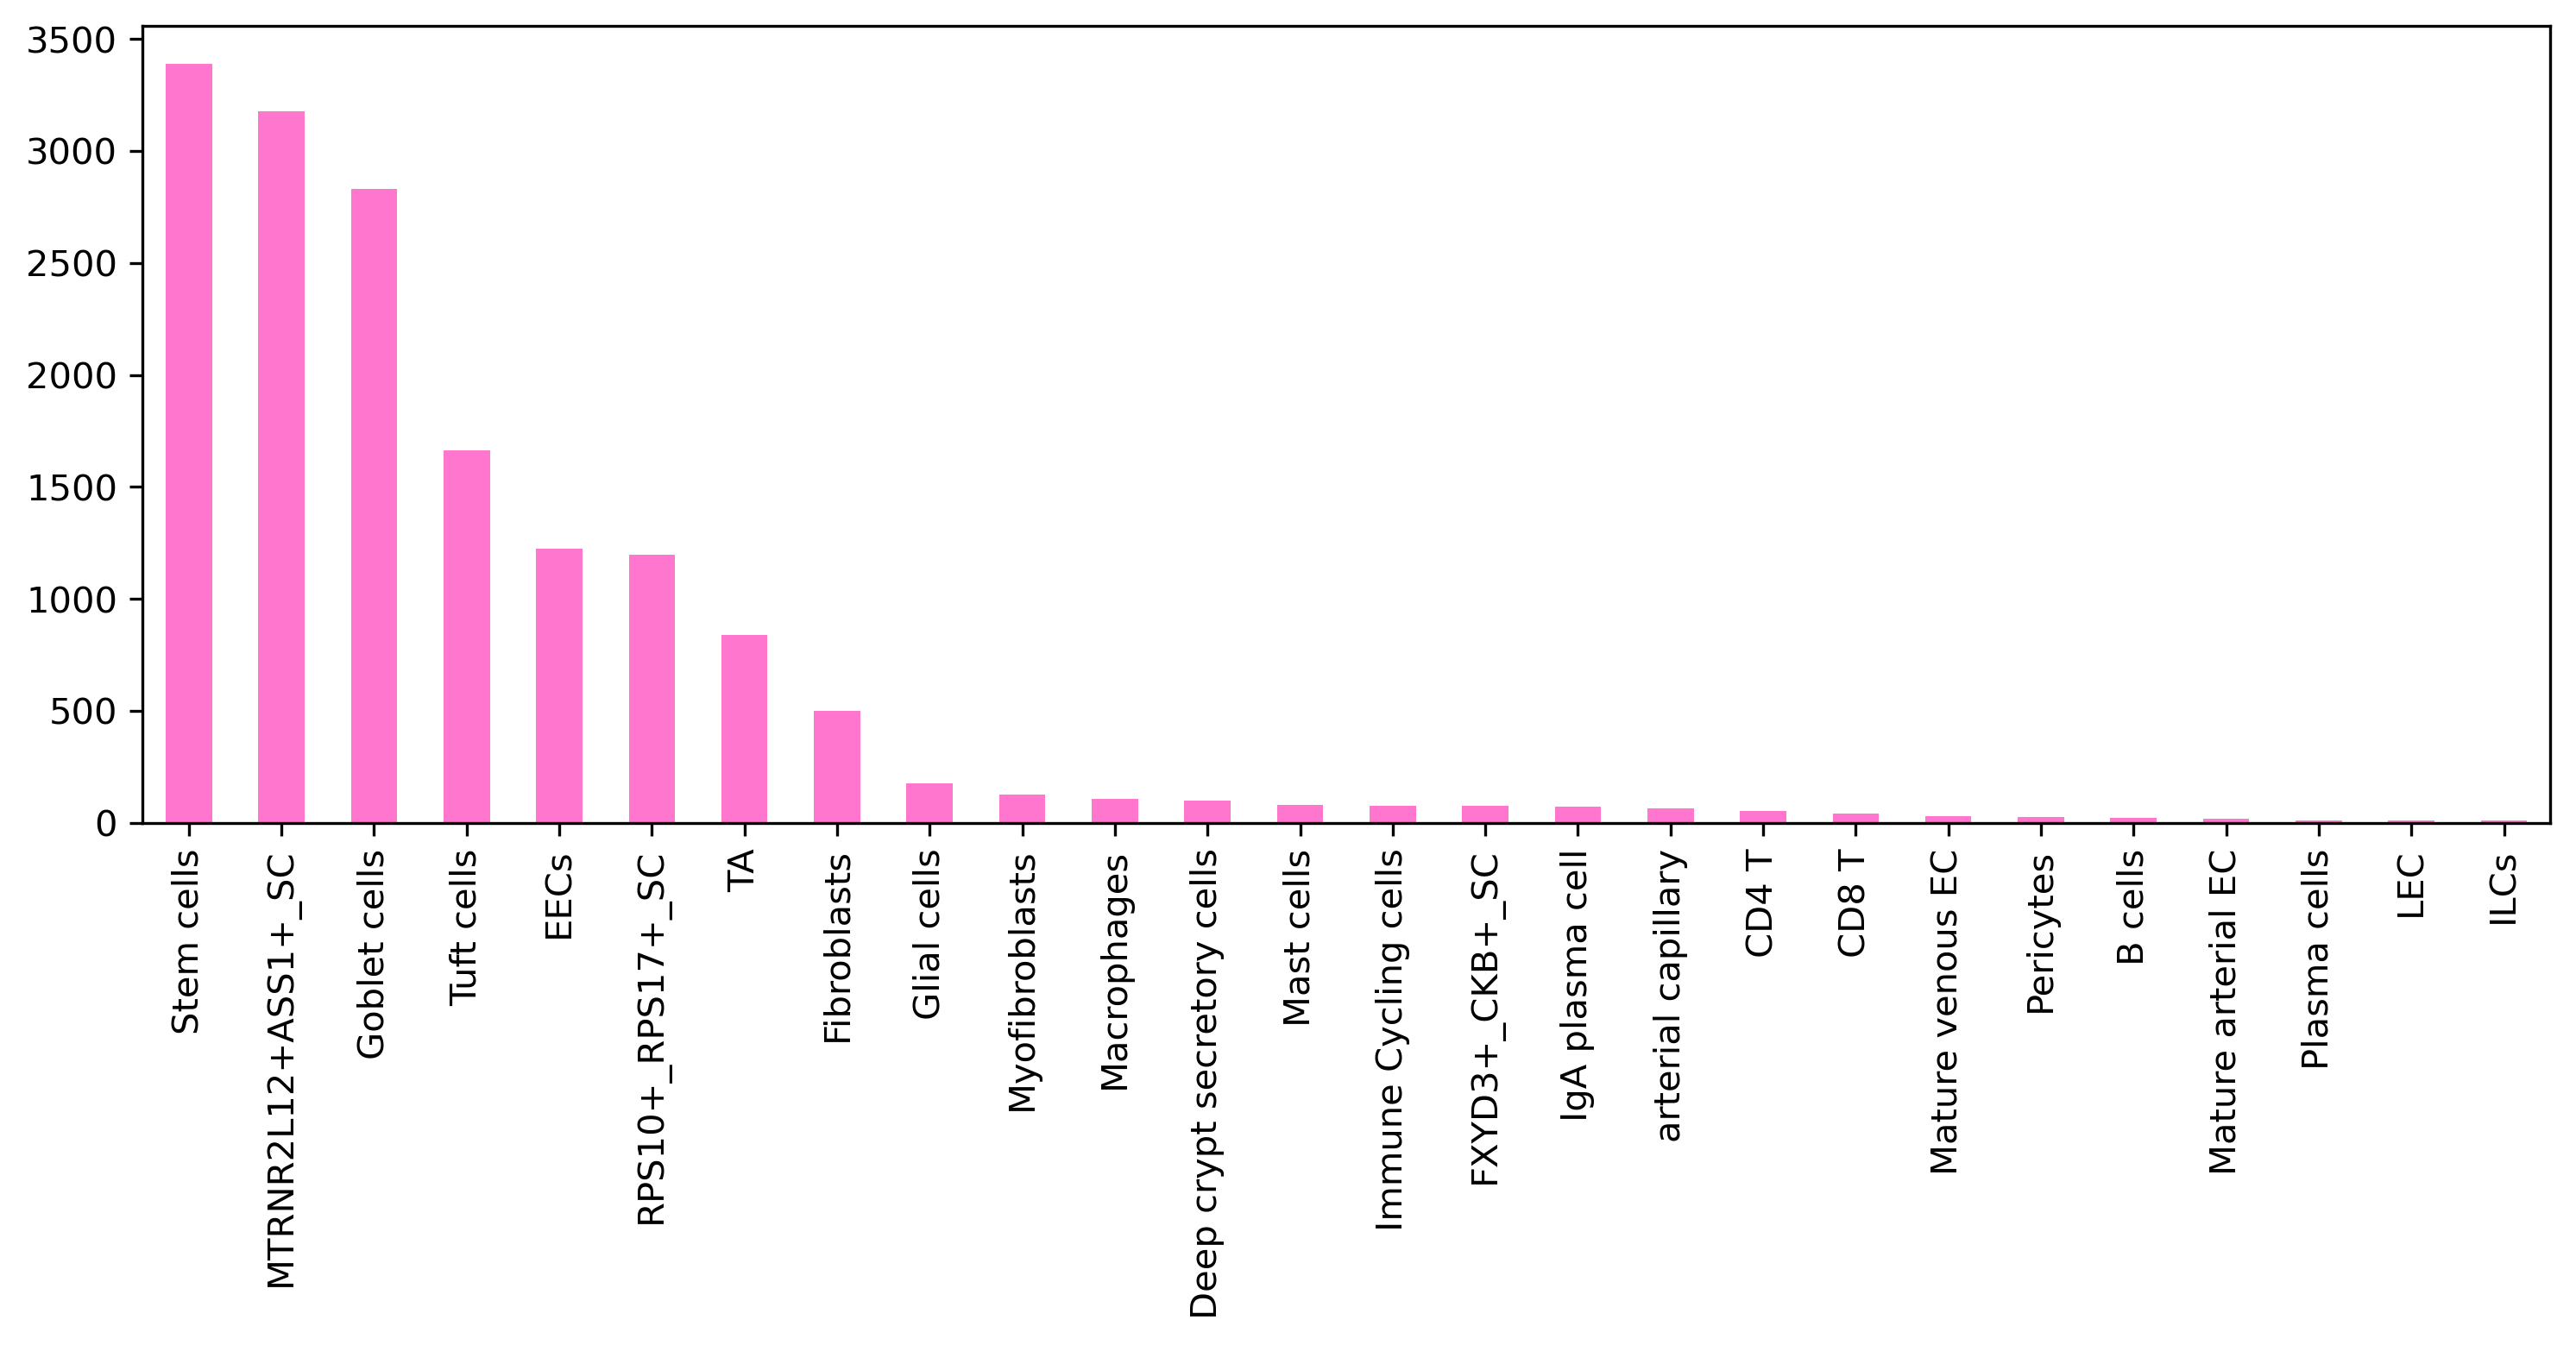

In [21]:
plt.figure(figsize=(12, 4), dpi=300)
sorted_stem_cell_niche.plot(kind='bar', color='#ff76ceff')
#('data/10X_Xenium_adult_colon_data/NicheCompass/Xenium_add_on/artifacts/single_sample/08082024_154509/figures/stem_cell_niche_composition.png', dpi=300, figsize=(20, 10))
plt.show()

In [19]:
df = pd.DataFrame({
    'Cell State': sorted_stem_cell_niche.index,
    'Number of Cells': sorted_stem_cell_niche.values
})

In [20]:
df

,Cell State,Number of Cells
0,Fibroblasts,4689
1,Stem cells,4152
2,Goblet cells,2318
3,Tuft cells,1728
4,Glial cells,1706
5,Macrophages,1475
6,CD4 T,1313
7,Mast cells,1195
8,Endothelial cells,1185
9,Plasma cells,1129


In [28]:
custom_color_26 = ['#43766C', '#759EB8', '#824670', '#FF76CE', '#E9A8F2', '#94FFD8','#A3D8FF', '#FFA27F', '#97BE5A', '#ff4a46ff',
                   '#97be5aff', '#9467bdff', '#34af85ff', '#15becfff', '#0000a6ff', '#a30159ff', '#8967B3', '#F05A7E', '#D7C3F1', '#00712D',
                   '#FFFBE6', '#FFF4B5', '#7EACB5', '#81DAE3', '#6A9C89', '#FF77B7']

In [11]:
custom_color_26 = [
    '#43766C',  # Stem cells, dark teal
    '#759EB8',  # MTRNR2L12+ASS1+_SC, steel blue
    '#824670',  # Goblet cells, deep purple
    '#FF76CE',  # Tuft cells, bright pink
    '#E9A8F2',  # EECs, light lavender
    '#94FFD8',  # RPS10+_RPS17+_SC, mint green
    '#A3D8FF',  # TA, light sky blue
    '#FFA27F',  # Fibroblasts, light coral
    '#982B1C',  # Glial cells, bricks color
    '#ff4a46',  # Myofibroblasts, bright red-orange
    '#97be5a',  # Macrophages, olive green (same as Glial cells)
    '#9467bd',  # Deep crypt secretory cells, medium purple
    '#34af85',  # Mast cells, sea green
    '#15becf',  # Immune Cycling cells, turquoise
    '#0000a6',  # FXYD3+_CKB+_SC, dark blue
    '#a30159',  # IgA plasma cell, deep magenta
    '#605678',  # Arterial capillary, purple-grey
    '#F05A7E',  # CD4 T, bright pink-red
    '#D7C3F1',  # CD8 T, pale lavender
    '#00712D',  # Mature venous EC, dark green
    '#FFFBE6',  # Pericytes, very pale yellow
    '#FFF4B5',  # B cells, light yellow
    '#7EACB5',  # Mature arterial EC, grayish blue-green
    '#81DAE3',  # Plasma cells, light turquoise
    '#6A9C89',  # LEC, muted teal
    '#FF77B7'   # ILCs, bright pink
]

In [31]:
custom_color_26 = [
    '#FF76CE',  # Stem cells, bright pink
    '#E9A8F2',  # MTRNR2L12+ASS1+_SC, light lavender
    '#94FFD8',  # Goblet cells, mint green
    '#A3D8FF',  # Tuft cells, light sky blue
    '#FFA27F',  # EECs, light coral
    '#43766C',  # RPS10+_RPS17+_SC, dark teal
    '#759EB8',  # TA, steel blue
    '#824670',  # Fibroblasts, deep purple
    '#982B1C',  # Glial cells, bricks color
    '#ff4a46',  # Myofibroblasts, bright red-orange
    '#97be5a',  # Macrophages, olive green (same as Glial cells)
    '#9467bd',  # Deep crypt secretory cells, medium purple
    '#34af85',  # Mast cells, sea green
    '#15becf',  # Immune Cycling cells, turquoise
    '#0000a6',  # FXYD3+_CKB+_SC, dark blue
    '#a30159',  # IgA plasma cell, deep magenta
    '#605678',  # Arterial capillary, purple-grey
    '#F05A7E',  # CD4 T, bright pink-red
    '#D7C3F1',  # CD8 T, pale lavender
    '#00712D',  # Mature venous EC, dark green
    '#FFFBE6',  # Pericytes, very pale yellow
    '#FFF4B5',  # B cells, light yellow
    '#7EACB5',  # Mature arterial EC, grayish blue-green
    '#81DAE3',  # Plasma cells, light turquoise
    '#6A9C89',  # LEC, muted teal
    #'#FF77B7'   # ILCs, bright pink
]

In [27]:
len(df['Number of Cells'])

25

In [32]:
len(custom_color_26)

25

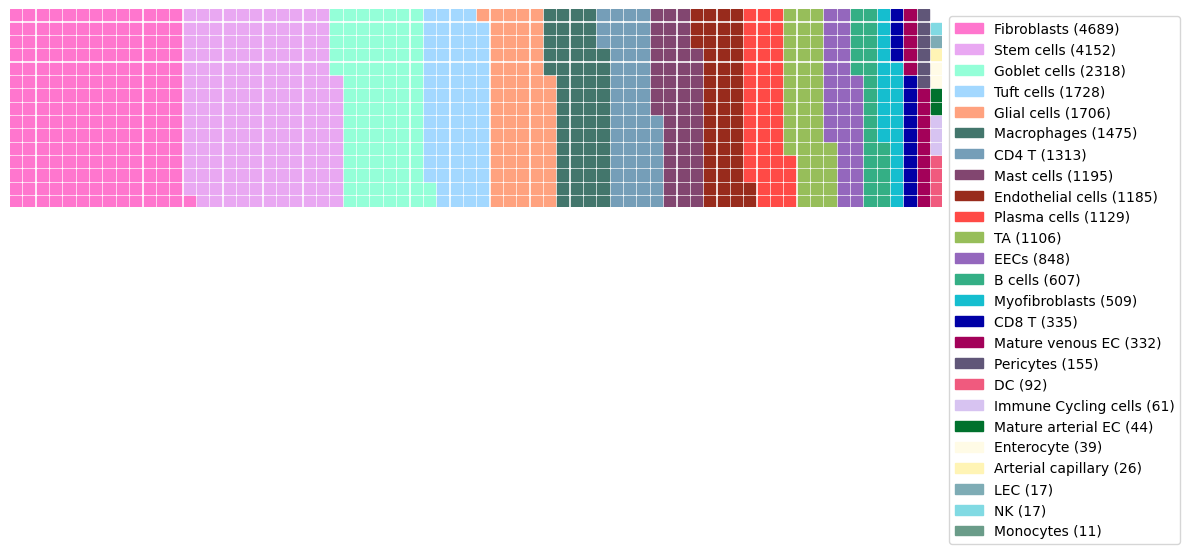

In [34]:
fig = plt.figure(
    FigureClass=Waffle,
    rows=15,
    columns=70,
    values=df['Number of Cells'],
    labels=[f"{label} ({value})" for label, value in zip(df['Cell State'], df['Number of Cells'])],
    legend={'loc': 'upper left', 'bbox_to_anchor': (1, 1)},
    figsize=(12, 8),
    colors=custom_color_26
)
plt.savefig('data/stem_cell_niche_composition_waffle.png', dpi=300)
plt.show()